In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
import cv2
import tensorflow as tf
from tensorflow.python.keras import Sequential
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
from IPython.display import display
from tensorflow.keras import backend as K
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import plotly.express as px
import plotly.graph_objects as go

from google.colab import files #Librería para cargar ficheros directamente en Colab
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
sales_df = pd.read_csv('/content/drive/My Drive/IA/AI in Marketing Dataset/sales_data_sample.csv', encoding='latin-1')

In [ ]:
sales_df

In [ ]:
sales_df.dtypes

MINI RETO #1
- Convertir la fecha del pedido en formato de fecha y hora usando pandas.
- Verificar que la conversión es correcta imprimiendo el tipo de datos

In [ ]:
# Convertir la fecha del pedido en formato de fecha y hora
sales_df ['ORDERDATE'] = pd.to_datetime(sales_df['ORDERDATE'])
sales_df.dtypes

MINI RETO #2:
- ¿Cuántos elementos nulos existen en 'ADDRESSLINE2'?



In [ ]:
# Comprobar el número de elementos no nulos del data frame
sales_df.info()

#Comprobar el numero de elementos nulos del data frame
sales_df.isnull().sum()

In [ ]:
# Dado que hay muchos valores nulos en 'addressline2', 'state', 'postal code' y 'territorio', podemos eliminarlos.
# Country representaría la información geográfica del pedido.
# También podemos eliminar la ciudad, la dirección1, el número de teléfono, el nombre del contacto, el apellido del contacto y el nombre del contacto, ya que no son necesarios para el análisis.

df_drop  = ['ADDRESSLINE1', 'ADDRESSLINE2', 'POSTALCODE', 'CITY', 'TERRITORY', 'PHONE', 'STATE', 'CONTACTFIRSTNAME', 'CONTACTLASTNAME', 'CUSTOMERNAME', 'ORDERNUMBER']
sales_df = sales_df.drop(df_drop, axis = 1)
sales_df.head()

MINI RETO 3#
- ¿Cuántos valores únicos existen en el 'pais'?
- ¿Cuántos códigos de producto únicos y líneas de productos tenemos?

In [ ]:
# Obtener las observaciones únicas de cada columna
sales_df.nunique()

#TAREA 3#: ANALISIS EXPLORATORIO DE LOS DATOS Y LIMPIEZA - PARTE 1

In [ ]:
sales_df ['COUNTRY'].value_counts().index


In [ ]:
sales_df ['COUNTRY'].value_counts()

In [ ]:
# Función para visualizar el recuento de elementos en una columna determinada
# Ten en cuenta que Plotly es una librería de gráficos de Python que crea gráficos interactivos con calidad de publicación.
# Compruébalo en: https://plotly.com/python/
# Nota: px (plotly_express) es un wrapper de alto nivel entorno a plotly para una rápida exploración de datos y generación de figuras
# Compruébalo en: https://plotly.github.io/plotly_express

def barplot_visualization(x):
  fig = plt.Figure(figsize = (12, 6))
  fig = px.bar(x = sales_df[x].value_counts().index, y = sales_df[x].value_counts(), color = sales_df[x].value_counts().index, height = 600)
  fig.show()

In [ ]:
# Llamemos a esta funcion para cualquier columna determinada , como 'COUNT'
barplot_visualization('COUNTRY')

MINI RETO 4#:

- ¿Cuántos valores de estado de pedido únicos tenemos?
- ¿Tenemos conjunto de datos balanceados? Comentar el resultado y proponer soluciones para solucionar el problema

In [ ]:
barplot_visualization('STATUS')

In [ ]:
sales_df.drop(columns = ['STATUS'], inplace = True)
sales_df

In [ ]:
barplot_visualization('PRODUCTLINE')

In [ ]:
barplot_visualization ('DEALSIZE')

In [ ]:
#Función para agregar variables ficticias para reemplazar variables categoricas

def dummies(x):
  dummy = pd.get_dummies (sales_df[x])
  sales_df.drop (columns = x, inplace = True)
  return pd.concat ([sales_df, dummy], axis = 1)

In [ ]:
sales_df = dummies('COUNTRY')
sales_df

MINI RETO 5#
- Obtener dummies para la linea de productos y columnas de tamaño de oferta.
- Realizar una prueba de verificación y ver si la transformación es correcta.

In [ ]:
sales_df = dummies('PRODUCTLINE')
sales_df

In [ ]:
sales_df = dummies('DEALSIZE')
sales_df

In [ ]:
y = pd.Categorical(sales_df['PRODUCTCODE'])
y

In [ ]:
y = pd.Categorical(sales_df['PRODUCTCODE']).codes
y

In [ ]:
# Dado que el número de código de producto tiene 109 valores únicos, si agregamos variables one-hot,
# serían 109 columnas adicionales, podemos evitarlo usando la codificación categórica
# Esta no es la forma óptima de lidiar con esto, pero es importante evitar la maldición de la dimensionalidad.
sales_df['PRODUCTCODE'] = pd.Categorical(sales_df['PRODUCTCODE']).codes
sales_df

TAREA #4: ANALISIS EXPLORATORIO DE LOS DATOS Y LIMPIEZA

In [ ]:
#Agrupamos los datos según la fecha del pedido
sales_df_group = sales_df.groupby(by = "ORDERDATE").sum()
sales_df_group

MINI RETO #6:
- Según los datos, ¿Cuándo alcanzan su punto máximo las ventas (en qué mes)?
- Apoya tu respuesta con visualzaciones / graficos

In [ ]:
fig = px.line(x = sales_df_group.index, y = sales_df_group.SALES, title = 'SALES')
fig.show()

In [ ]:
#Podemos eliminar 'ORDERDATE' y quedarnos con el resto de datos relacionados
sales_df.drop("ORDERDATE", axis = 1, inplace = True)
sales_df.shape

MINI RETO #7:
- Representar la matriz de correlación enre variables
- Comentar los ressultados de la matriz

<Axes: >

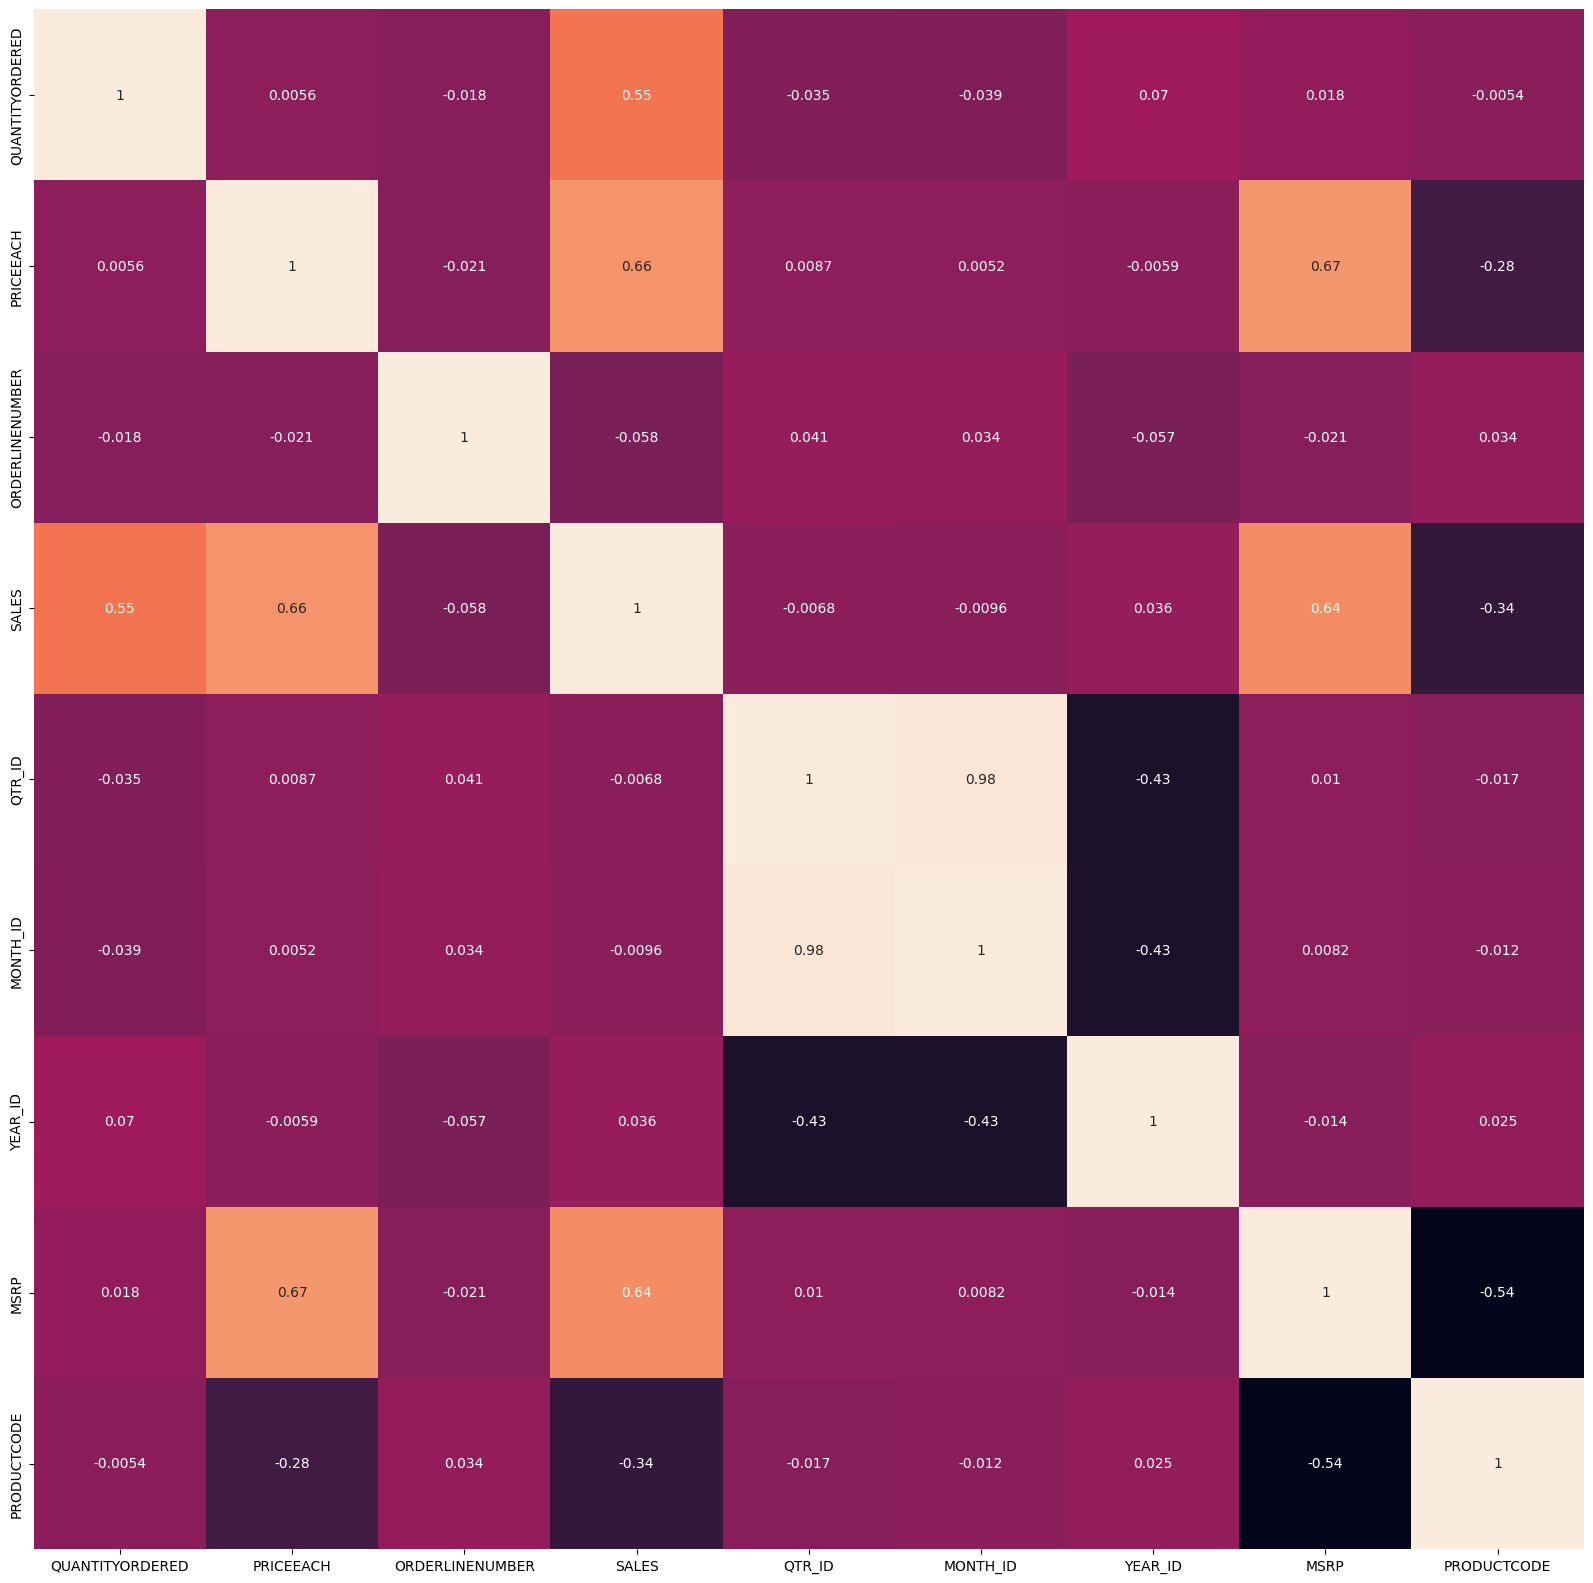

In [ ]:
plt.figure(figsize = (20, 20))
corr_matrix = sales_df.iloc [:, :9].corr()
sns.heatmap(corr_matrix, annot = True, cbar = False)

In [ ]:
# Parece que el ID del trimestre y los ID del mes de estan  altamente correlacionales
sales_df.drop("QTR_ID", axis = 1, inplace = True)
sales_df.shape

(2823, 37)

In [ ]:
# Vamos a representar distribuciones
# Distplot muestra el (1) histograma, (2) kde plot y (3) rug plot.
# (1) Histograma: es una visualización gráfica de datos que usa barras con varias alturas. Cada barra agrupa los números en rangos y las barras más altas muestran que hay más datos en ese rango.
# (2) Densidad: la estimación de la función de densidad se utiliza para visualizar la densidad de probabilidad de una variable continua.
# (3) Gráfico de alfombra: gráfico de datos para una única variable cuantitativa, que se muestra como marcas a lo largo de un eje (gráfico de dispersión unidimensional).

import plotly.figure_factory as ff

plt.figure(figsize = (10, 10))

for i in range(8):
  if sales_df.columns[i] != 'ORDERLINENUMBER':
    col_name = sales_df.columns[i]
    fig = ff.create_distplot([sales_df[col_name].apply(lambda x: float(x))], ['distplot'])
    fig.update_layout(title_text = col_name)
    fig.show()

<Figure size 1000x1000 with 0 Axes>

In [ ]:
plt.figure(figsize =(15, 15))

fig = px.scatter_matrix(sales_df,dimensions = sales_df.columns [:8], color = 'MONTH_ID')
fig.update_layout (
    title = 'Sales Data',
    width =1100,
    height = 1100,
)
fig.show()

<Figure size 1500x1500 with 0 Axes>

TAREA #6: Encuentre el numero óptimo de clusteres utilizando el metodo del codo

- El método del codo es un método heurstico de interpretación

In [ ]:
#Escalamos los datos
scaler = StandardScaler()
sales_df_scaled = scaler.fit_transform(sales_df)

In [ ]:
sales_df_scaled.shape

(2823, 37)

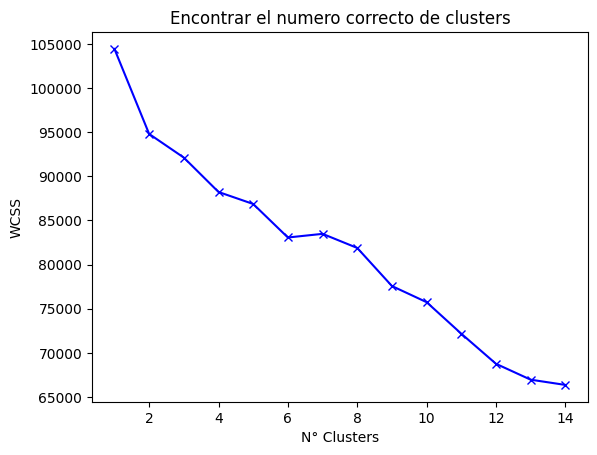

In [ ]:
scores = []

range_values = range(1, 15)

for i in range_values:
  kmeans = KMeans (n_clusters=i)
  kmeans.fit (sales_df_scaled)
  scores.append(kmeans.inertia_) # la inercia es la suma de los cuadrados de las distancias de las observaciones al centro del cluster más cercano

plt.plot(range_values, scores, 'bx-')
plt.title ('Encontrar el numero correcto de clusters')
plt.xlabel('N° Clusters')
plt.ylabel('WCSS')
plt.show()

# Detalles de Kmeans en Sklearn: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
# A partir de esto podemos observar que, el 5º grupo parece estar formando el codo de la curva.
# Tengamos en cuenta que la curva cambiará cada vez que ejecutemos la celda

# TAREA #7: APLICAR EL MÉTODO K-MEANS

In [ ]:
#Agrupar los datos usando k-means
kmeans = KMeans(5)
kmeans.fit(sales_df_scaled)
labels = kmeans.labels_

In [ ]:
labels

array([3, 3, 1, ..., 1, 3, 1], dtype=int32)

In [ ]:
cluster_centers = pd.DataFrame(data = kmeans.cluster_centers_, columns = [sales_df.columns])
cluster_centers

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,Austria,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,-0.160985,-0.025489,0.000815,-0.144341,0.056315,0.011599,-0.066346,-0.143803,3.776170,-0.140961,...,-0.128067,0.047699,0.095620,-0.260560,-0.133535,0.012549,0.256605,-0.170350,-0.030247,0.108780
1,0.456059,0.493154,-0.031440,0.366060,-0.019687,0.048033,0.025738,0.156971,-0.264819,-0.058650,...,-0.436535,0.116468,0.075826,0.124360,0.007155,0.200071,0.119067,-0.237708,1.017401,-0.912100
2,0.303035,0.748685,-0.042648,1.157375,-0.005607,-0.023154,1.236118,-0.870411,-0.234996,0.179414,...,1.117140,-0.198140,-0.289325,-0.300637,-0.156127,-0.303624,-0.424571,0.956877,0.429158,-0.871338
3,-0.468228,-0.729695,0.037436,-0.811853,0.008004,0.001461,-0.605149,0.324004,-0.264819,-0.007915,...,-0.183015,0.019323,0.087917,0.096355,0.074461,-0.053239,0.075553,-0.242672,-0.980703,1.096370
4,-0.016027,-0.017022,0.099384,0.053142,0.012797,-0.423279,0.132777,-0.129105,-0.264819,-0.140961,...,0.131743,-0.325106,-0.348674,-0.116996,0.221106,0.597843,-0.092018,-0.021737,-0.018495,0.028576


In [ ]:
kmeans.cluster_centers_.shape

(5, 37)

In [ ]:
cluster_centers = pd.DataFrame(data = kmeans.cluster_centers_, columns = [sales_df.columns])
cluster_centers

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,Austria,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,-0.160985,-0.025489,0.000815,-0.144341,0.056315,0.011599,-0.066346,-0.143803,3.776170,-0.140961,...,-0.128067,0.047699,0.095620,-0.260560,-0.133535,0.012549,0.256605,-0.170350,-0.030247,0.108780
1,0.456059,0.493154,-0.031440,0.366060,-0.019687,0.048033,0.025738,0.156971,-0.264819,-0.058650,...,-0.436535,0.116468,0.075826,0.124360,0.007155,0.200071,0.119067,-0.237708,1.017401,-0.912100
2,0.303035,0.748685,-0.042648,1.157375,-0.005607,-0.023154,1.236118,-0.870411,-0.234996,0.179414,...,1.117140,-0.198140,-0.289325,-0.300637,-0.156127,-0.303624,-0.424571,0.956877,0.429158,-0.871338
3,-0.468228,-0.729695,0.037436,-0.811853,0.008004,0.001461,-0.605149,0.324004,-0.264819,-0.007915,...,-0.183015,0.019323,0.087917,0.096355,0.074461,-0.053239,0.075553,-0.242672,-0.980703,1.096370
4,-0.016027,-0.017022,0.099384,0.053142,0.012797,-0.423279,0.132777,-0.129105,-0.264819,-0.140961,...,0.131743,-0.325106,-0.348674,-0.116996,0.221106,0.597843,-0.092018,-0.021737,-0.018495,0.028576


In [ ]:
cluster_centers = scaler.inverse_transform (cluster_centers)
cluster_centers = pd.DataFrame(data = cluster_centers, columns = [sales_df.columns])
cluster_centers
# Clúster 0 (más alto): este grupo representa a los clientes que compran artículos en una gran cantidad centrada en ~ 47, compran artículos en todos los rangos de precios inclinándose hacia artículos de alto precio de ~ 99. También corresponden a las ventas totales más altas alrededor de ~ 8296 y están activas durante todo el año. Son los mayores compradores de productos con un MSRP alto ~ 158.
# Clúster 1: este grupo representa a los clientes que compran artículos en cantidades variables ~ 35, tienden a comprar artículos de alto precio ~ 96. Sus ventas son un poco mejores en promedio ~ 4435, compran productos con el segundo MSRP más alto de ~ 133.
# Clúster 2 (más bajo): este grupo representa a los clientes que compran artículos en cantidades bajas ~ 30. Suelen comprar artículos de bajo precio ~ 68. Sus ventas ~ 2044 son más bajas que las de otros grupos y son extremadamente activos durante la temporada navideña. Compran productos con un MSRP bajo ~ 75.
# Clúster 3: este grupo representa a los clientes que solo están activos durante las vacaciones. compran en menor cantidad ~ 35, pero tienden a comprar artículos de precio promedio alrededor de ~ 86. También corresponden a ventas totales más bajas alrededor de ~ 3673, tienden a comprar artículos con MSRP alrededor de 102.
# Clúster 4: este grupo representa a los clientes que compran artículos en cantidad variable ~ 39

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,Austria,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,33.524862,83.144420,6.469613,3288.079392,7.298343,2003.823204,98.049724,49.232044,1.000000e+00,-6.245005e-17,...,0.281768,0.132597,1.381215e-01,1.104972e-02,0.005525,0.110497,0.320442,1.657459e-02,4.751381e-01,5.082873e-01
1,39.534699,93.605802,6.333333,4228.002662,7.020478,2003.848692,101.749716,58.730375,5.412337e-16,1.137656e-02,...,0.135381,0.154721,1.319681e-01,1.171786e-01,0.028441,0.168373,0.263936,1.137656e-03,9.988623e-01,-3.497203e-15
2,38.044280,98.760055,6.285978,5685.240000,7.071956,2003.798893,150.383764,26.285978,7.380074e-03,4.428044e-02,...,0.872694,0.053506,1.845018e-02,1.054712e-15,0.001845,0.012915,0.040590,2.749077e-01,7.047970e-01,2.029520e-02
3,30.532399,68.940088,6.624343,2058.829816,7.121716,2003.816112,76.400175,64.005254,6.245005e-16,1.838879e-02,...,0.255692,0.123468,1.357268e-01,1.094571e-01,0.039405,0.090193,0.246060,4.579670e-16,-1.054712e-15,1.000000e+00
4,34.936709,83.315190,6.886076,3651.752025,7.139241,2003.518987,106.050633,49.696203,1.387779e-17,-1.734723e-17,...,0.405063,0.012658,-1.526557e-16,5.063291e-02,0.063291,0.291139,0.177215,5.063291e-02,4.810127e-01,4.683544e-01


In [ ]:
labels.shape # Etiquetas del cluster asociado a cada observación

(2823,)

In [ ]:
labels.max()

np.int32(4)

In [ ]:
labels.min()

np.int32(0)

In [ ]:
y_kmeans = kmeans.fit_predict(sales_df_scaled)
y_kmeans

array([3, 3, 2, ..., 1, 1, 1], dtype=int32)

In [ ]:
y_kmeans.shape

(2823,)

In [ ]:
#Agregar una etiqueta (cluster) correspondiente a cada punto de datos
sales_df_cluster = pd.concat([sales_df, pd.DataFrame({'cluster':labels})], axis = 1)
sales_df_cluster

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,Austria,...,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small,cluster
0,30,95.70,2,2871.00,2,2003,95,0,False,False,...,True,False,False,False,False,False,False,False,True,3
1,34,81.35,5,2765.90,5,2003,95,0,False,False,...,True,False,False,False,False,False,False,False,True,3
2,41,94.74,2,3884.34,7,2003,95,0,False,False,...,True,False,False,False,False,False,False,True,False,1
3,45,83.26,6,3746.70,8,2003,95,0,False,False,...,True,False,False,False,False,False,False,True,False,1
4,49,100.00,14,5205.27,10,2003,95,0,False,False,...,True,False,False,False,False,False,False,True,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,12,2004,54,108,False,False,...,False,False,True,False,False,False,False,False,True,3
2819,29,100.00,1,3978.51,1,2005,54,108,False,False,...,False,False,True,False,False,False,False,True,False,1
2820,43,100.00,4,5417.57,3,2005,54,108,False,False,...,False,False,True,False,False,False,False,True,False,1
2821,34,62.24,1,2116.16,3,2005,54,108,False,False,...,False,False,True,False,False,False,False,False,True,3


In [ ]:
sales_df['ORDERLINENUMBER'] = sales_df['ORDERLINENUMBER'].apply(lambda x: float(x))

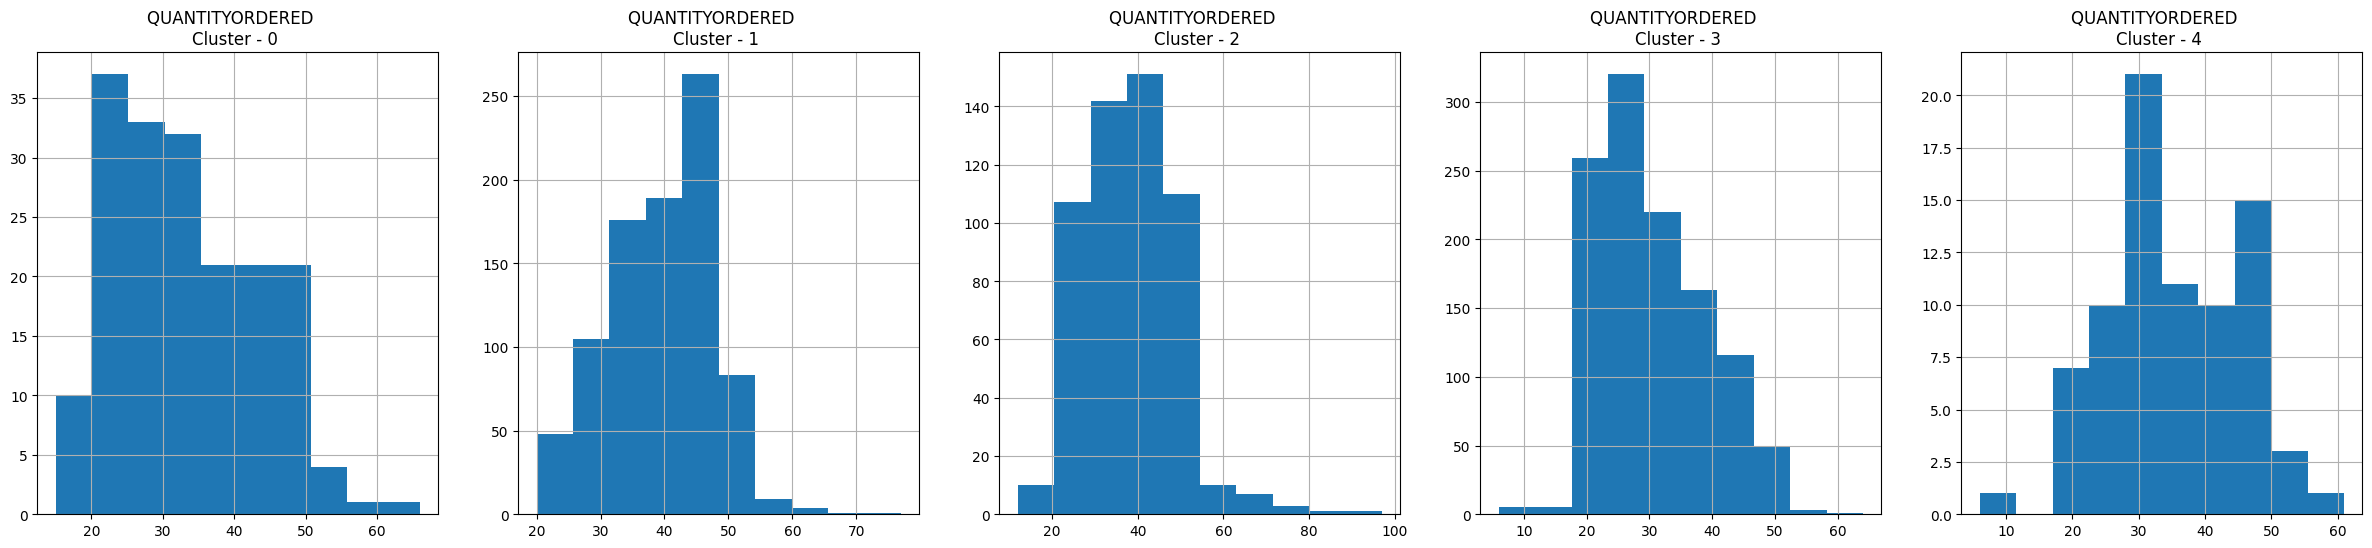

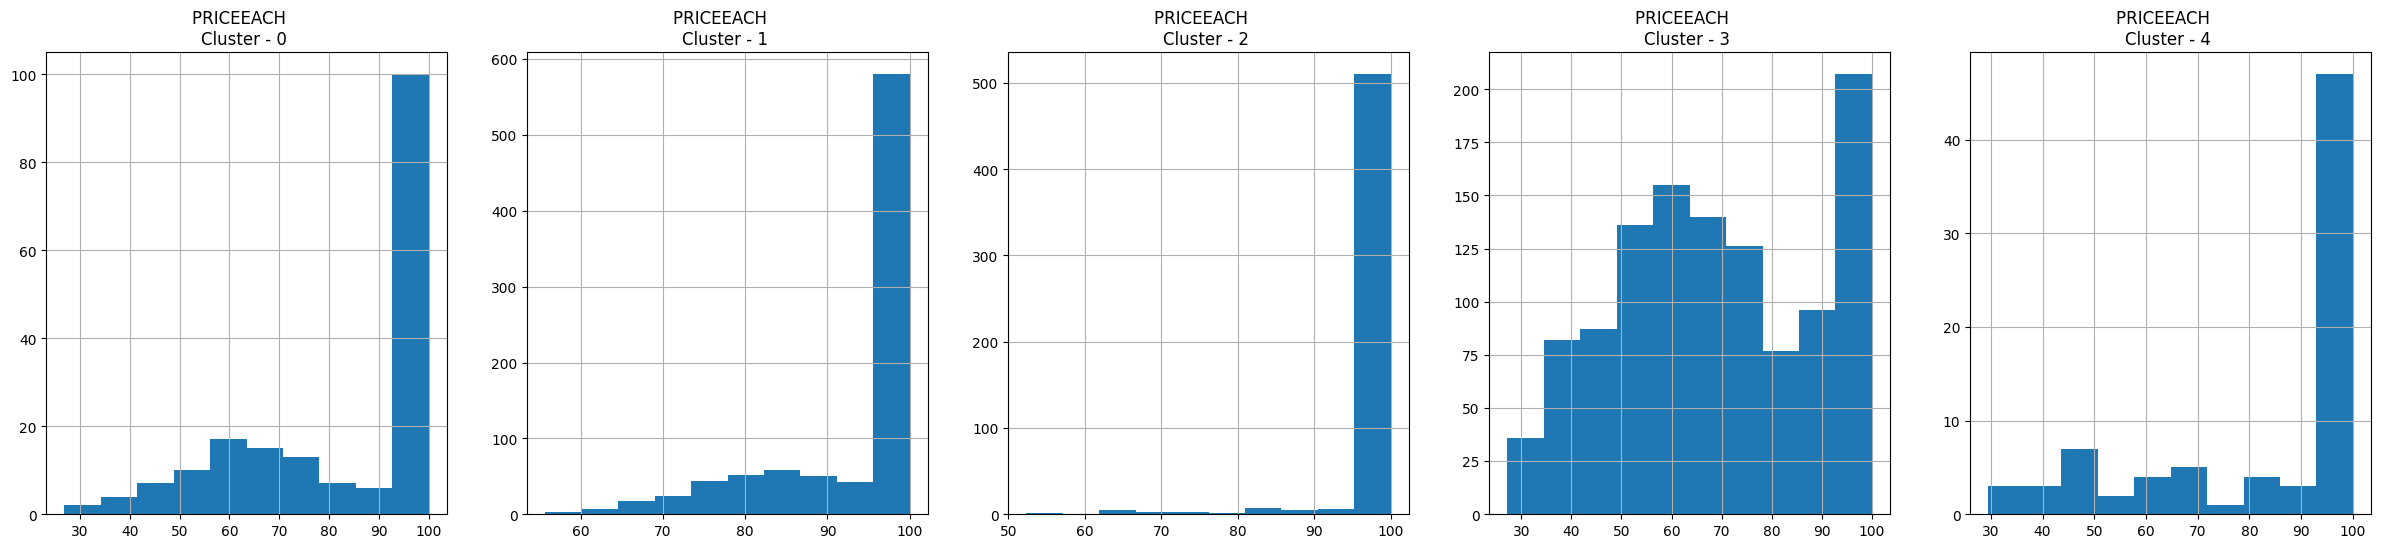

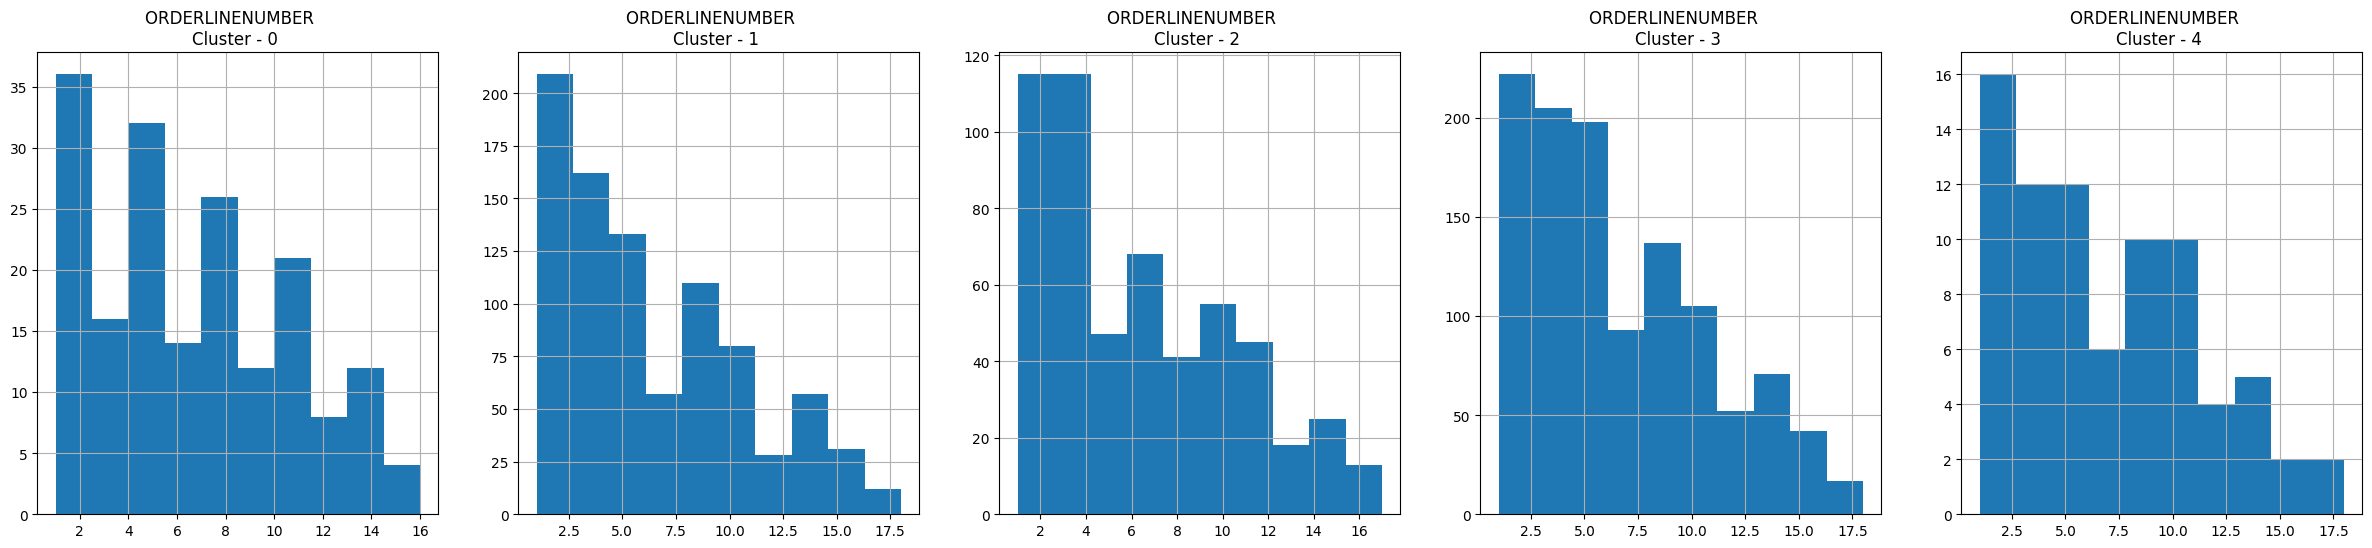

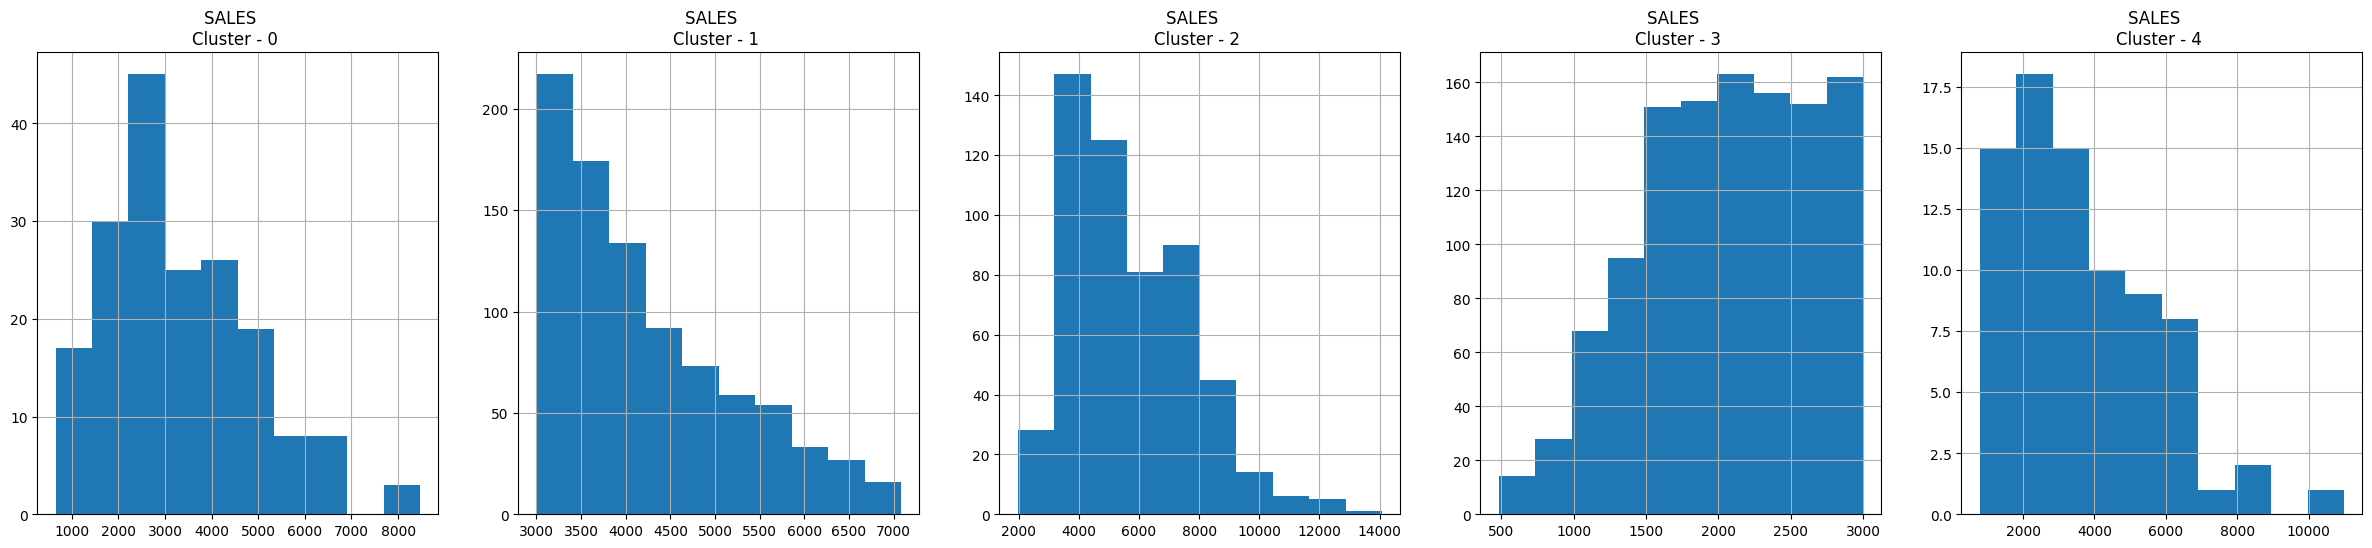

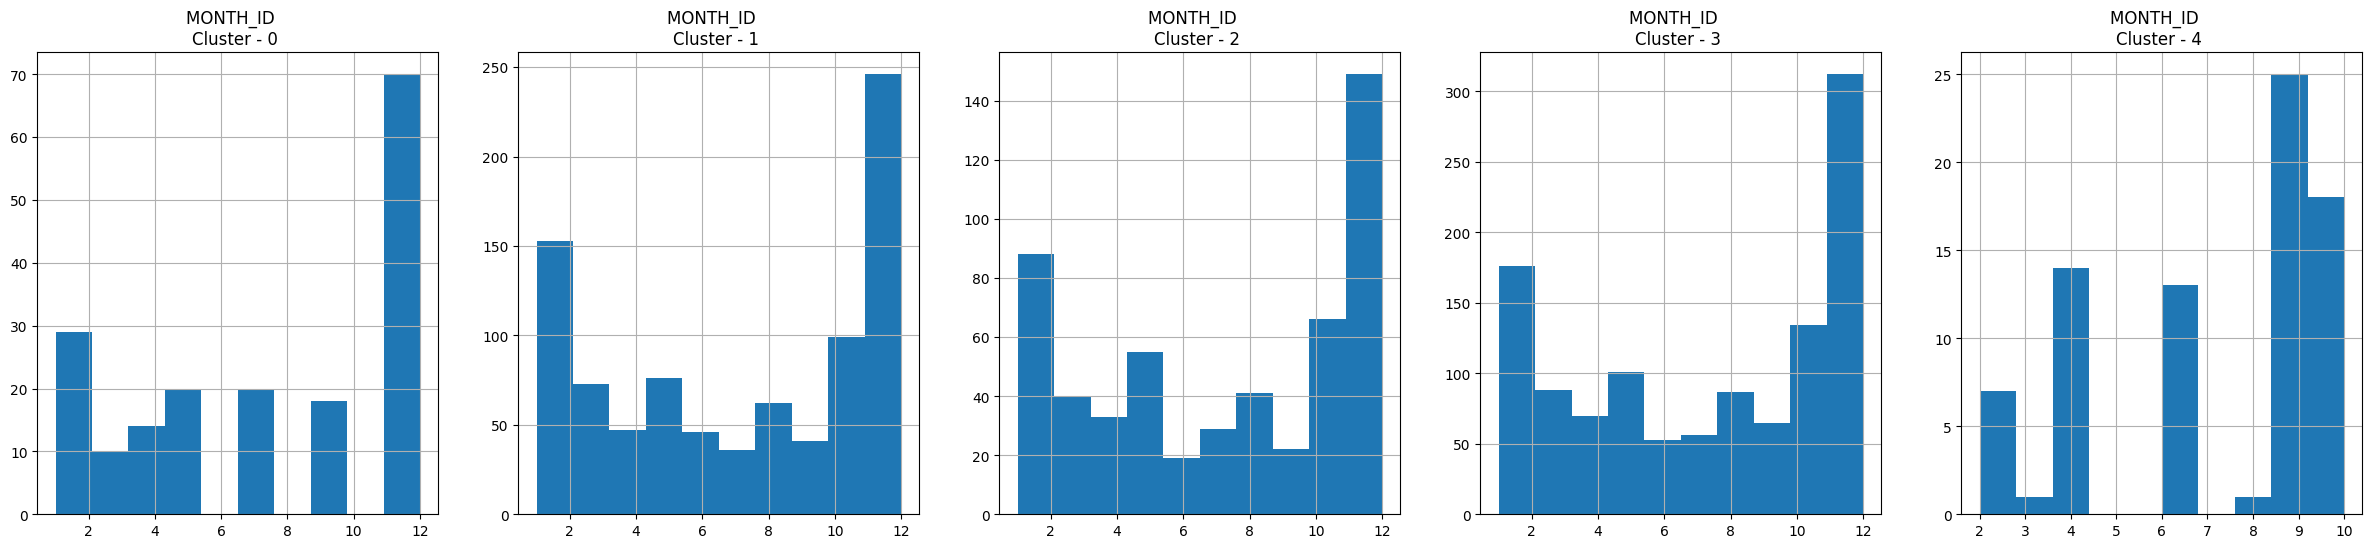

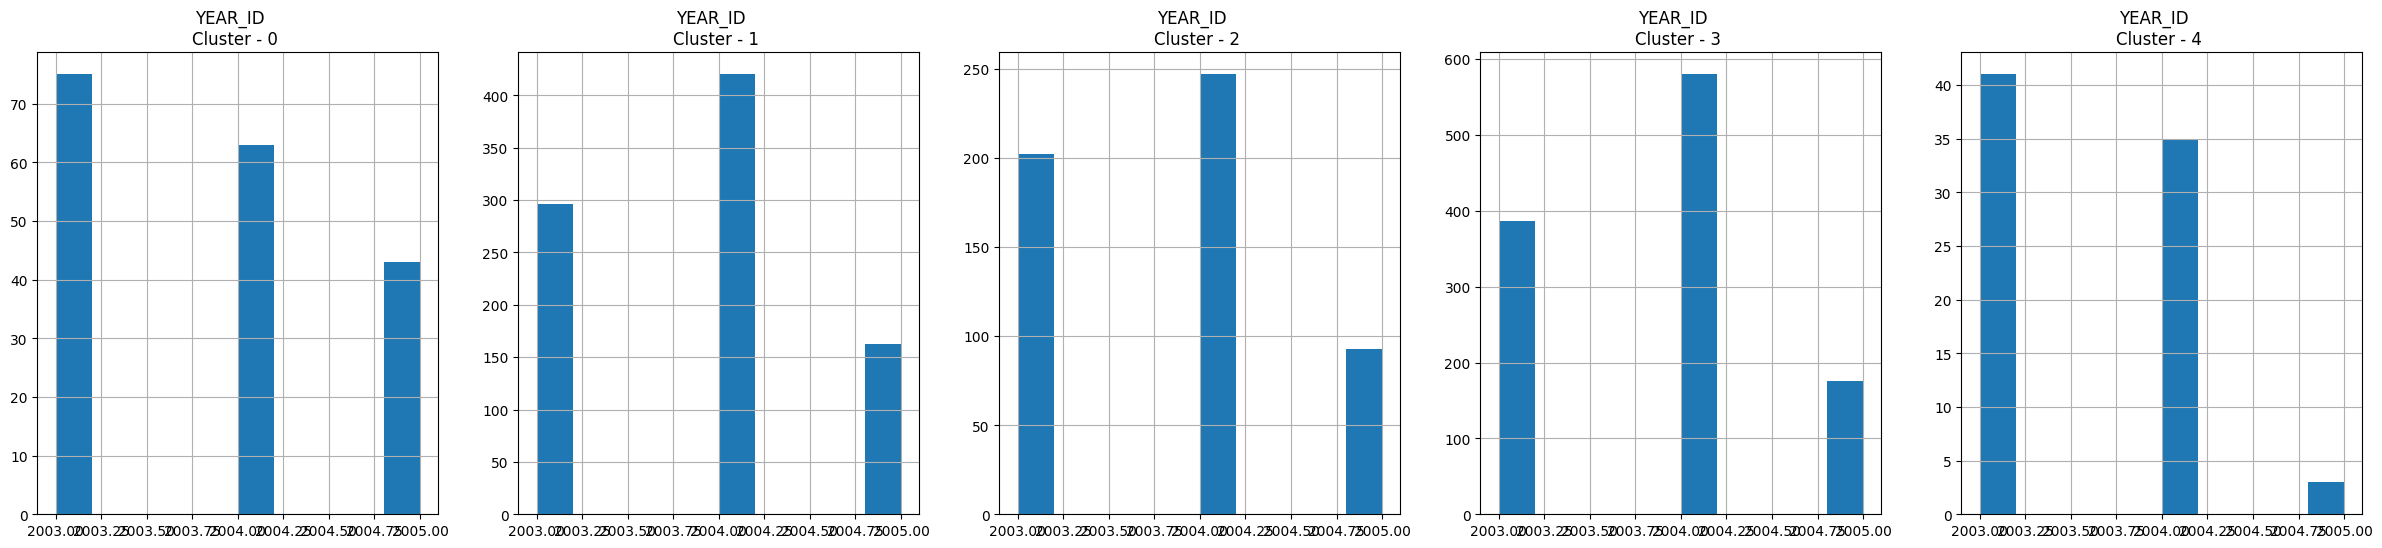

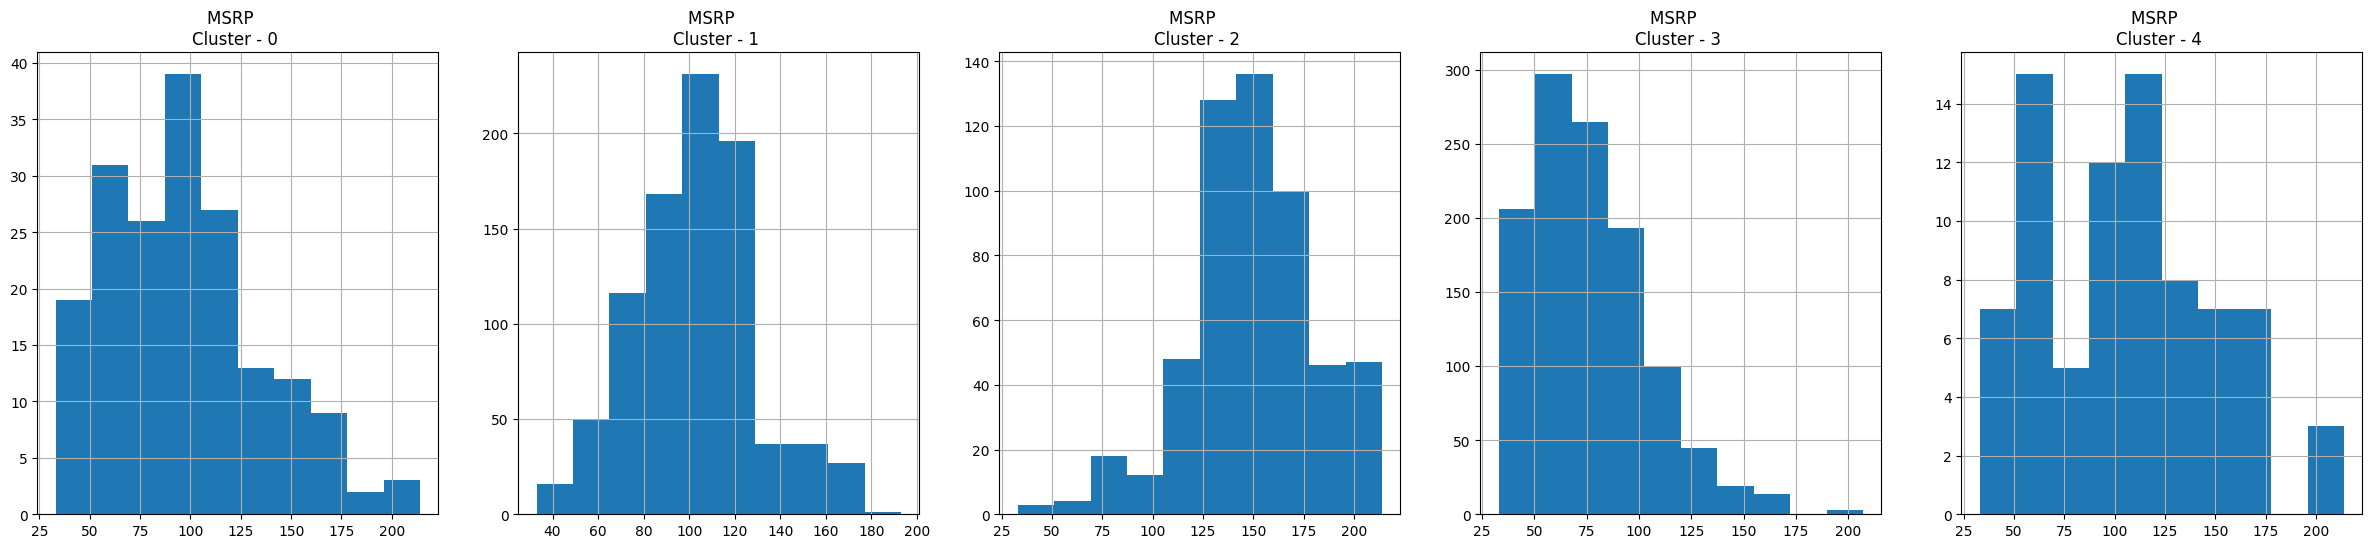

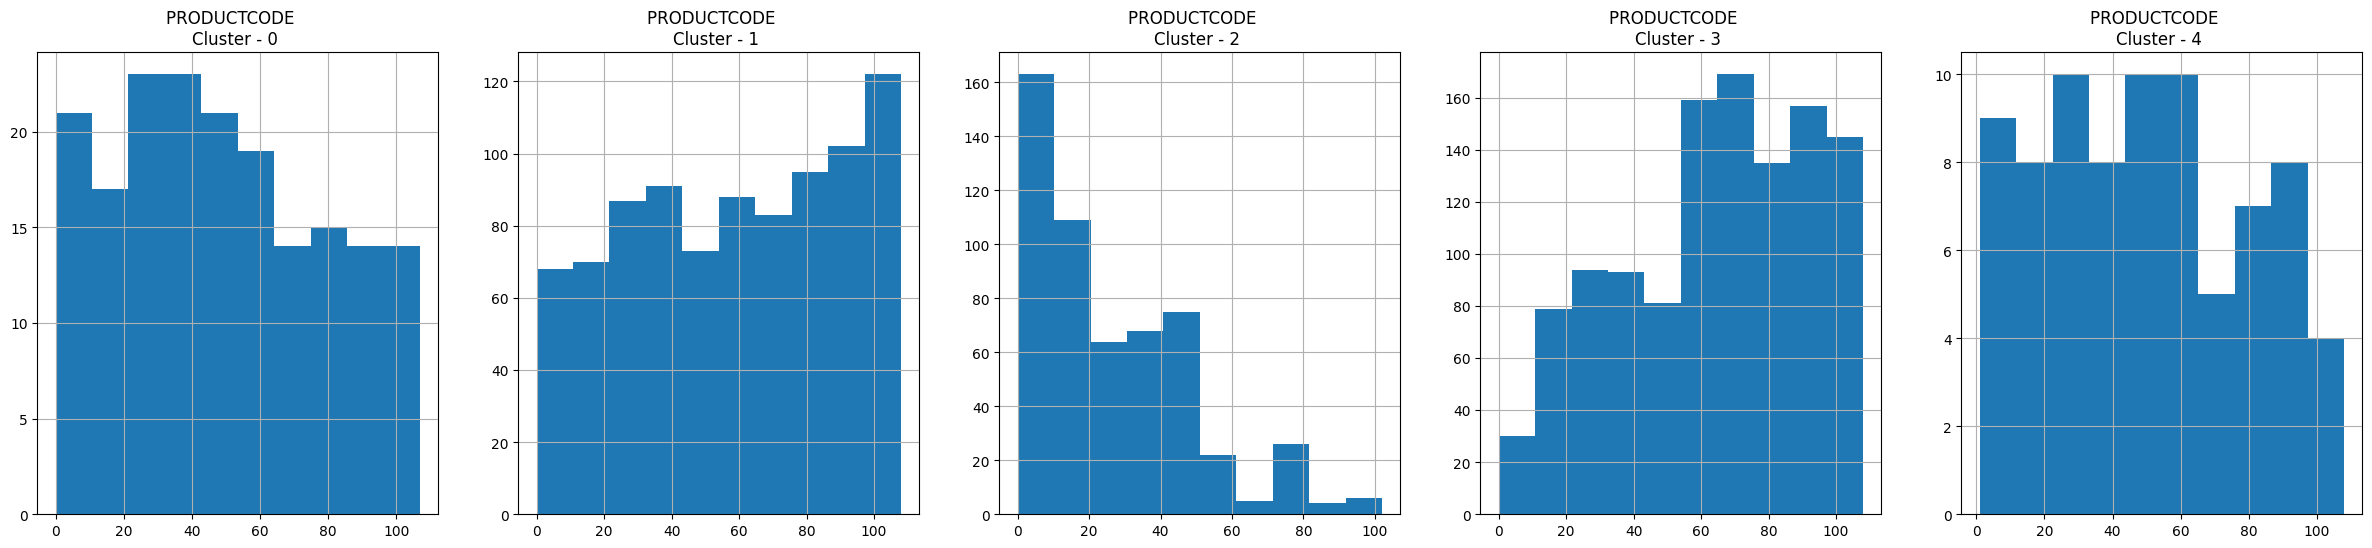

In [ ]:
# Presentar un histograma para cada caracteristica según el cluster al que pertenece
for i in sales_df.columns [:8]:
  plt.figure (figsize = (30, 6))
  for j in range (5):
    plt.subplot(1, 5, j+1)
    cluster = sales_df_cluster[sales_df_cluster['cluster']==j]
    cluster[i].hist()
    plt.title('{}   \nCluster - {} '.format(i, j))
  plt.show()

TAREA #8 APLICAR EL ANALISIS DE COMPONENTES PRINCIPALES Y VISUALIZACIÓN LOS RESULTADOS

In [ ]:
# Reducir los datos originales a 3 dimensiones usando PCA para visualizar los clústeres
pca = PCA (n_components=3)
principal_comp = pca.fit_transform (sales_df_scaled)
principal_comp

array([[-0.48631933,  1.19523199, -1.00267727],
       [-0.78465471,  1.03283188, -1.4162651 ],
       [ 1.43146434, -0.12199648, -0.28129104],
       ...,
       [ 0.38985361, -4.12946409,  0.06056817],
       [-2.78886764, -2.38601395, -1.54986594],
       [-0.7054888 , -3.31242744,  0.51890644]])

In [ ]:
# leer el libro la guia del viajero intergalactico

In [ ]:
pca_df = pd.DataFrame(data = principal_comp, columns= ['pca1', 'pca2', 'pca3'])
pca_df.head()

,pca1,pca2,pca3
0,-0.486319,1.195232,-1.002677
1,-0.784655,1.032832,-1.416265
2,1.431464,-0.121996,-0.281291
3,1.288425,0.218280,0.579360
4,1.976022,0.141698,1.061314


In [ ]:
# Concatenar las etiquetas de los clústeres al dataframe
pca_df = pd.concat([pca_df, pd.DataFrame({'cluster':labels})], axis = 1)
pca_df

,pca1,pca2,pca3,cluster
0,-0.486319,1.195232,-1.002677,3
1,-0.784655,1.032832,-1.416265,3
2,1.431464,-0.121996,-0.281291,1
3,1.288425,0.218280,0.579360,1
4,1.976022,0.141698,1.061314,1
...,...,...,...,...
2818,-2.450314,-1.113172,1.523553,3
2819,-0.158247,-3.709748,-0.640182,1
2820,0.389854,-4.129464,0.060568,1
2821,-2.788868,-2.386014,-1.549866,3


In [ ]:
#Visualizar los clústeres con 3D-Scatterplot
fig= px.scatter_3d(pca_df, x= 'pca1', y= 'pca2', z= 'pca3',
                   color = 'cluster', symbol = 'cluster', size_max =18, opacity = 0.7)
fig.update_layout(margin =dict(l=0, r=0, b=0, t=0))


MINI RETO #8:
- Cambia el número de componentes a 2, modifica el codigo y vuelve a ejecutar el modelos
- Visualiza los clústers usando gráficos 2D

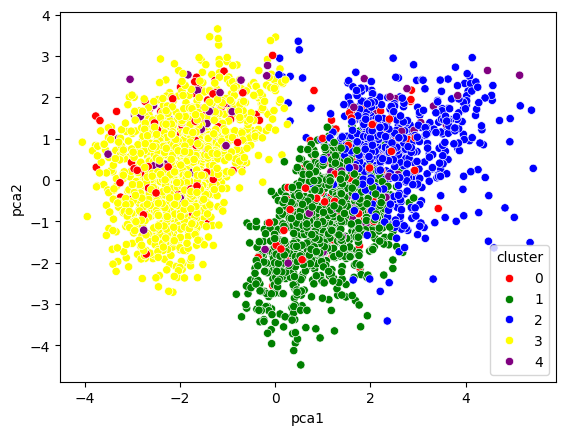

In [ ]:
pca = PCA (n_components = 2)
principal_comp= pca.fit_transform(sales_df_scaled)

pca_df = pd.DataFrame(data = principal_comp, columns = ['pca1', 'pca2'])
pca_df = pd.concat([pca_df, pd.DataFrame({'cluster':labels})], axis = 1)
ax = sns.scatterplot(x = 'pca1', y = 'pca2', hue = 'cluster', data = pca_df, palette = ["red", "green", "blue", "yellow", "purple"])
plt.show()

TAREA #9: ENTENDER LA TEORIA Y LA INTUCIÓN DETRÁS DE AUTOENCODERS

TAREA #10 APLICAR AUTOENCODERS (REALIZAR REDUCCIÓN DE DIMENSIONALIDAD USANDO AUTOENCODERS)

In [ ]:
sales_df.shape

(2823, 37)

In [ ]:
input_df = Input(shape = (37,))
x = Dense (50, activation = 'relu')(input_df)
x = Dense (500, activation='relu', kernel_initializer= 'glorot_uniform')(x)
x = Dense (500, activation='relu', kernel_initializer= 'glorot_uniform')(x)
x = Dense (2000, activation = 'relu', kernel_initializer= 'glorot_uniform')(x)
encoded = Dense (8, activation = 'relu', kernel_initializer= 'glorot_uniform')(x)
x = Dense (2000, activation = 'relu', kernel_initializer= 'glorot_uniform')(encoded)
x = Dense (500, activation = 'relu', kernel_initializer= 'glorot_uniform')(x)
decoded = Dense (37, kernel_initializer= 'glorot_uniform')(x)

# Autoencoder
autoencoder= Model(input_df, decoded)

encoder = Model(input_df, encoded)

autoencoder.compile(optimizer = 'adam', loss = 'mean_squared_error')


In [ ]:
autoencoder.fit(sales_df_scaled, sales_df_scaled, batch_size= 128, epochs =500, verbose = 3)

In [ ]:
# https://keras3.posit.co/reference/initializer_glorot_uniform.html

In [ ]:
autoencoder.save_weights('autoencoder_1.weights.h5')

In [ ]:
pred = encoder.predict(sales_df_scaled)

In [ ]:
pred

In [ ]:
scores = []

range_values = range(1, 15)

for i in range_values:
  kmeans = KMeans (n_clusters=i)
  kmeans.fit (pred)
  scores.append(kmeans.inertia_)

plt.plot(range_values, scores, 'bx-')
plt.title ('Encontrar el numero correcto de clusters')
plt.xlabel('N° Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(3)
kmeans.fit(pred)
labels = kmeans.labels_
y_kmeans = kmeans.fit_predict(sales_df_scaled)

In [ ]:
df_cluster_dr = pd.concat([sales_df, pd.DataFrame({'cluster':labels})], axis = 1)
df_cluster_dr.head()

In [ ]:
cluster_centers = pd.DataFrame (data = kmeans.cluster_centers_, columns = [sales_df.columns])
cluster_centers

In [ ]:
cluster_centers = scaler.inverse_transform (cluster_centers)
cluster_centers = pd.DataFrame(data = cluster_centers, columns=[sales_df.columns])
cluster_centers

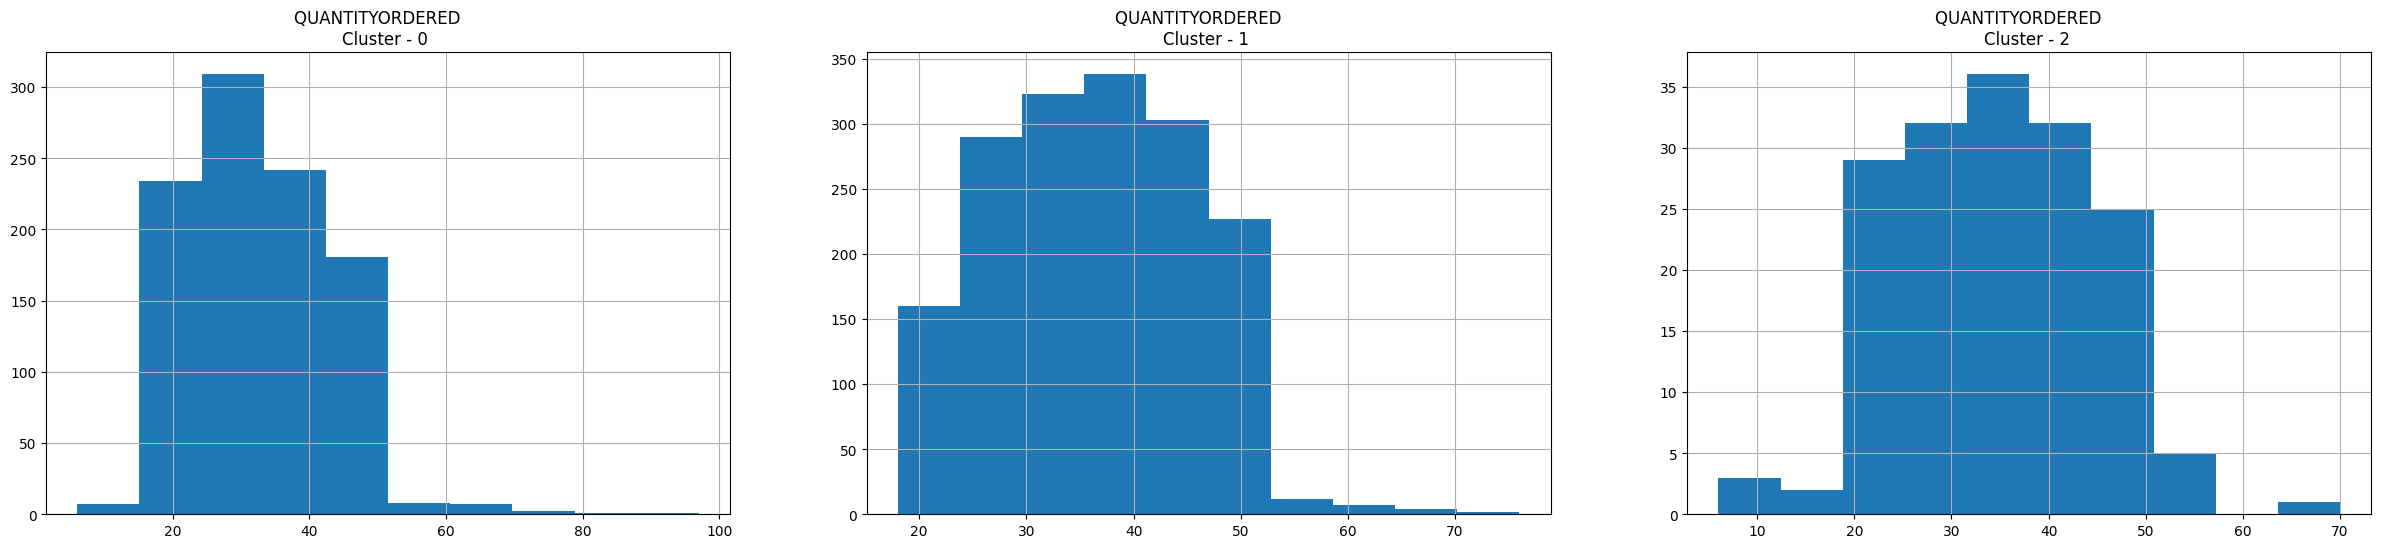

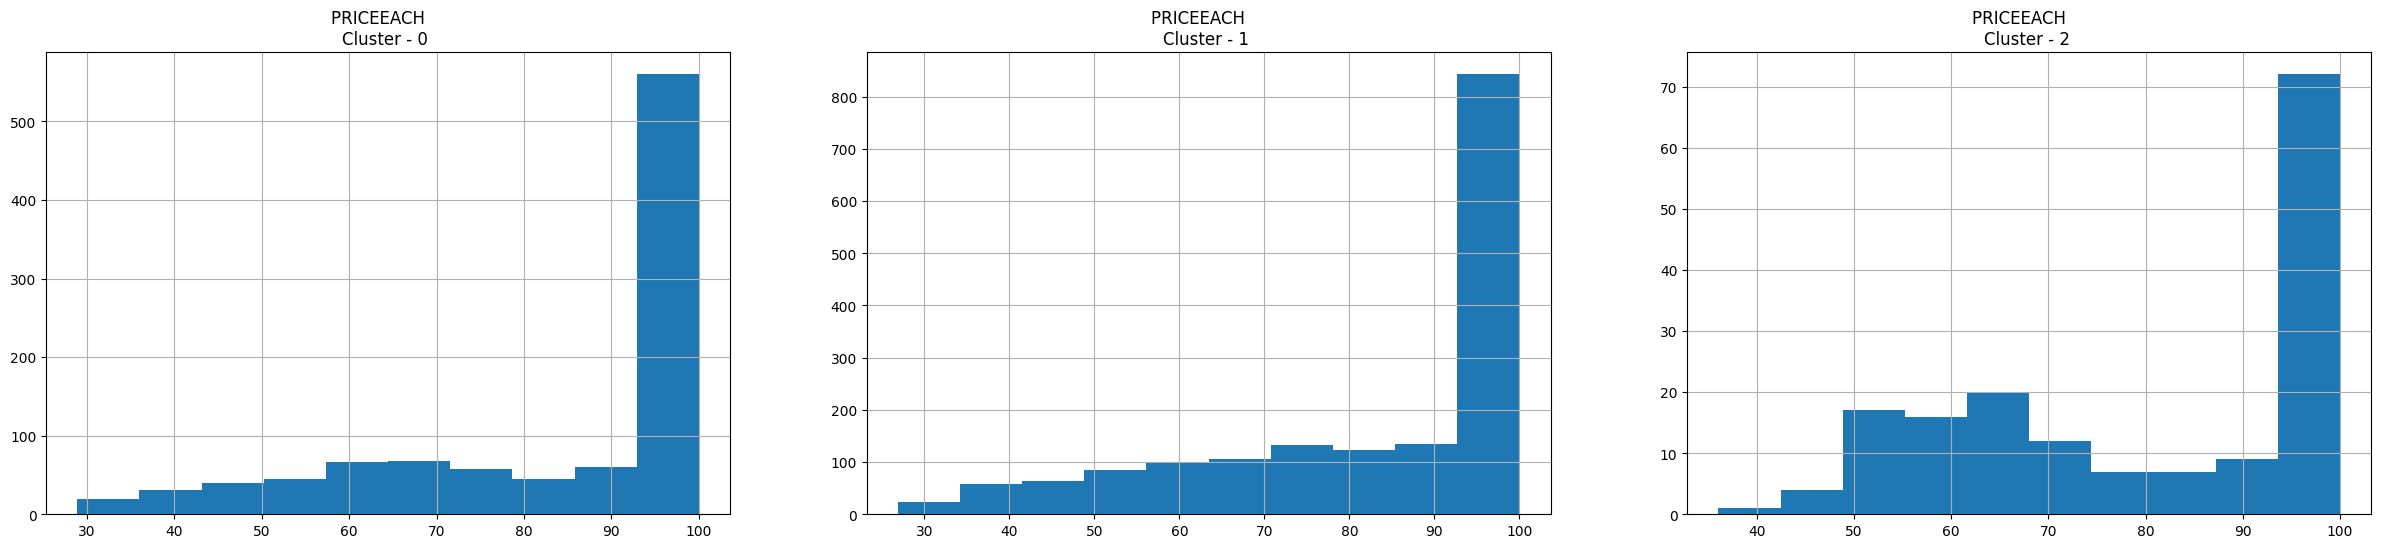

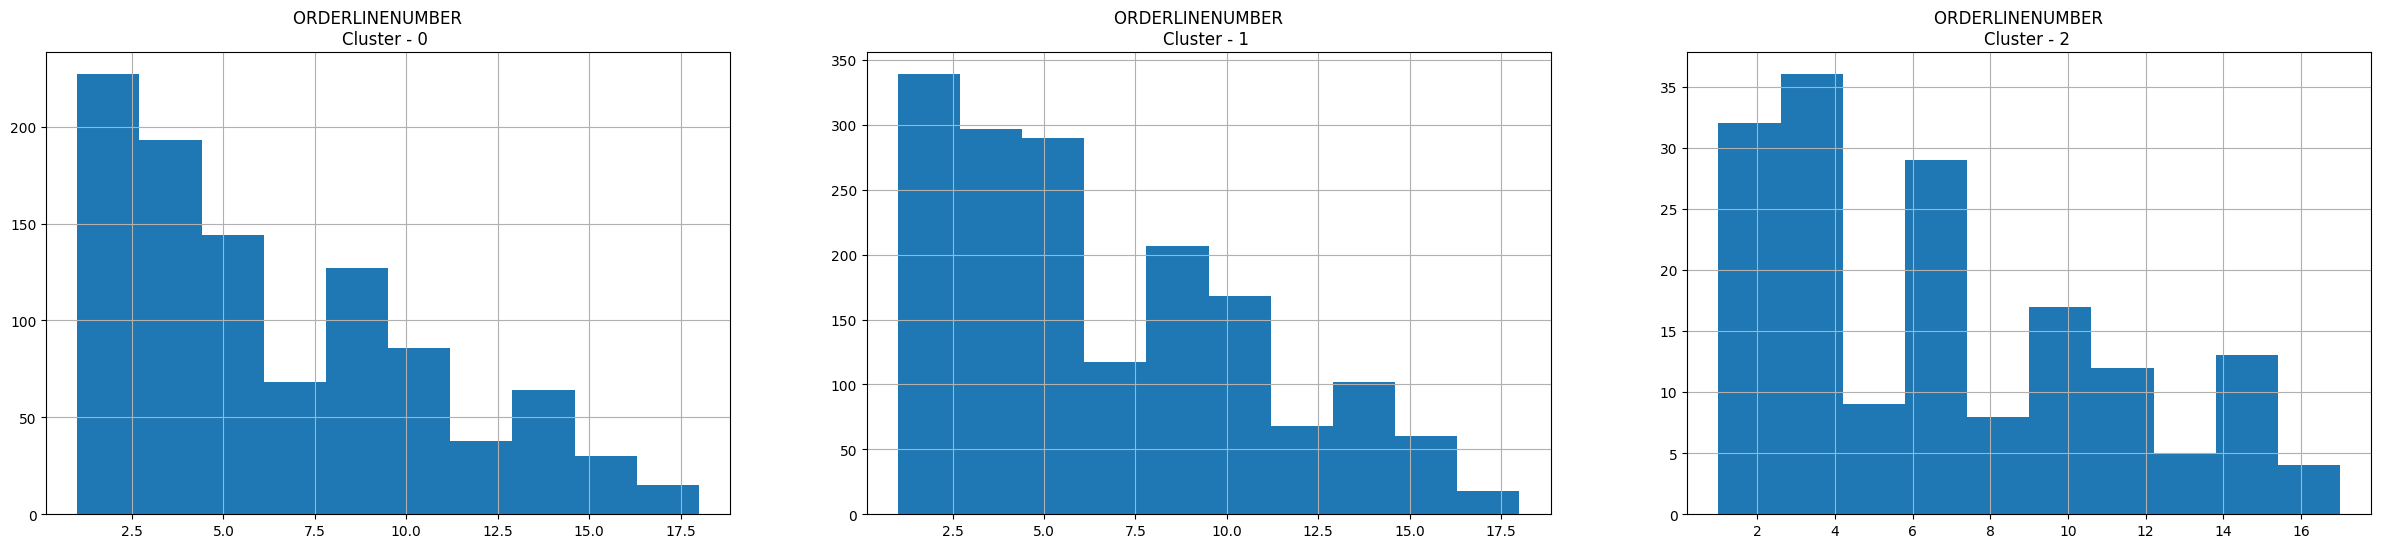

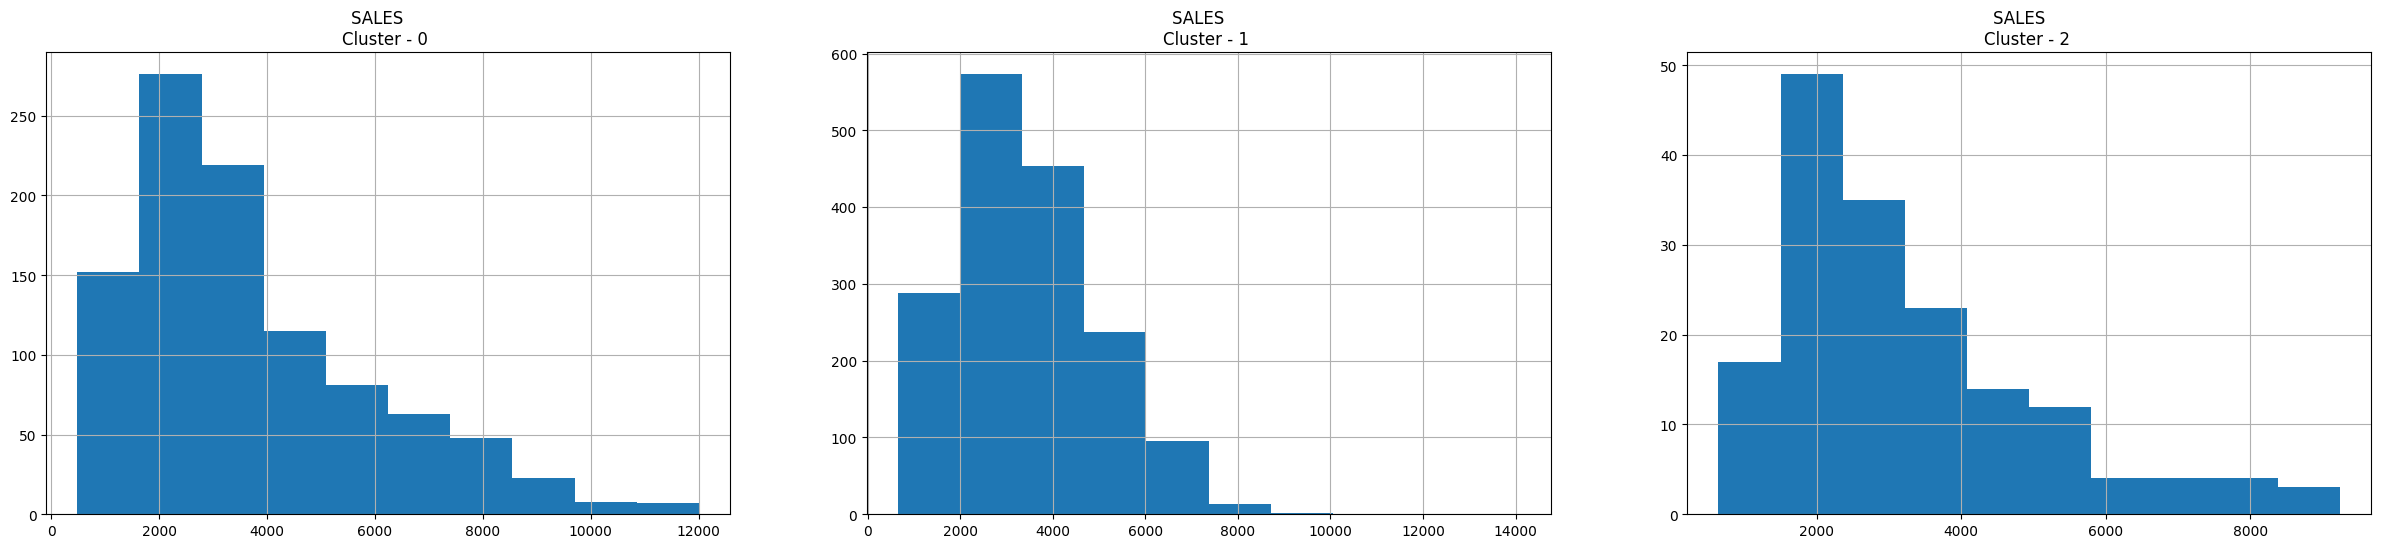

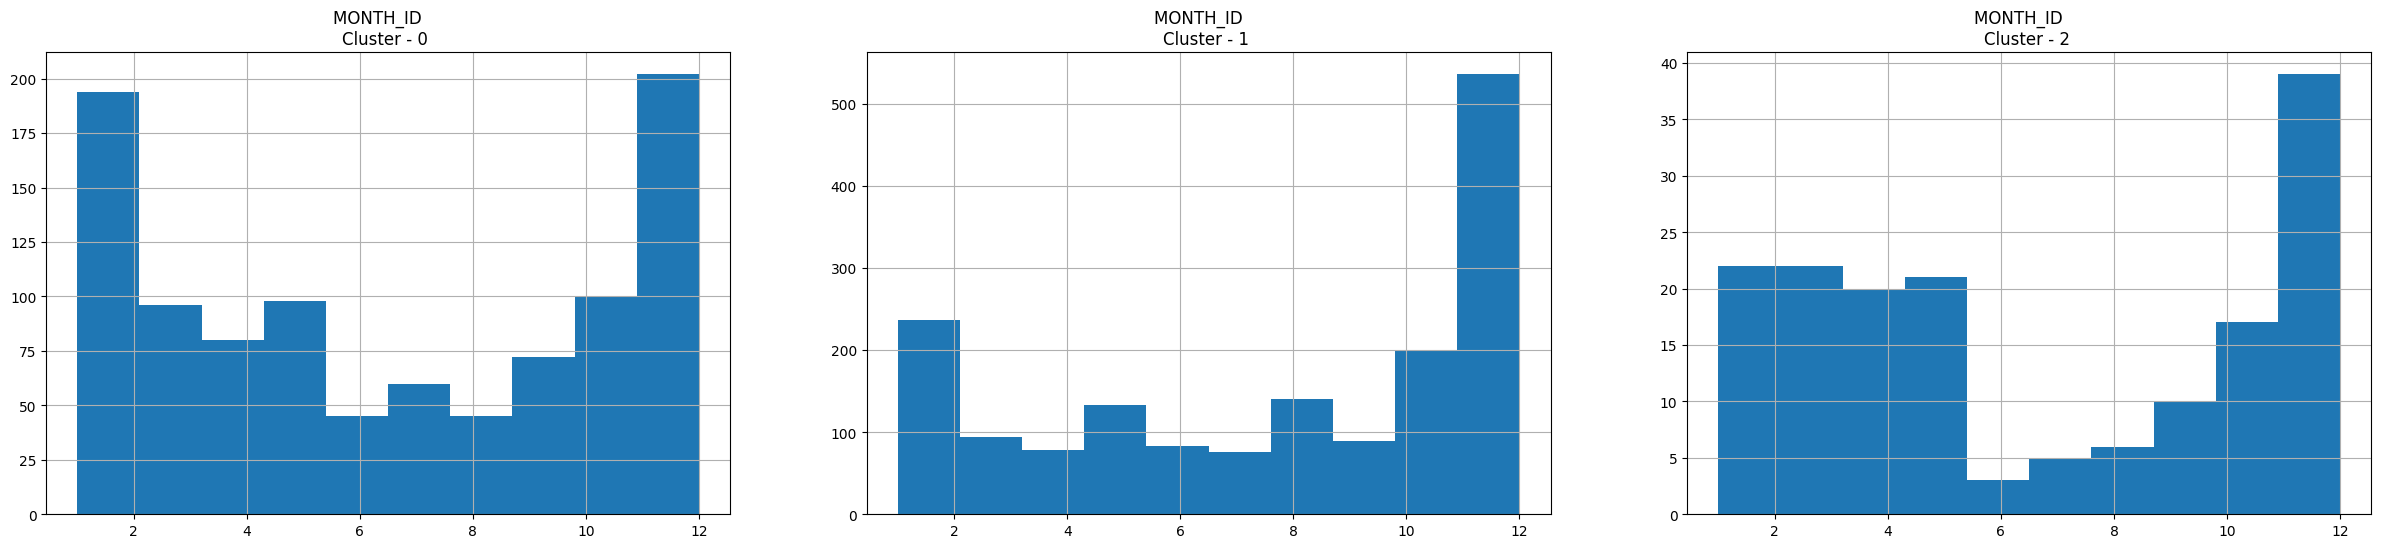

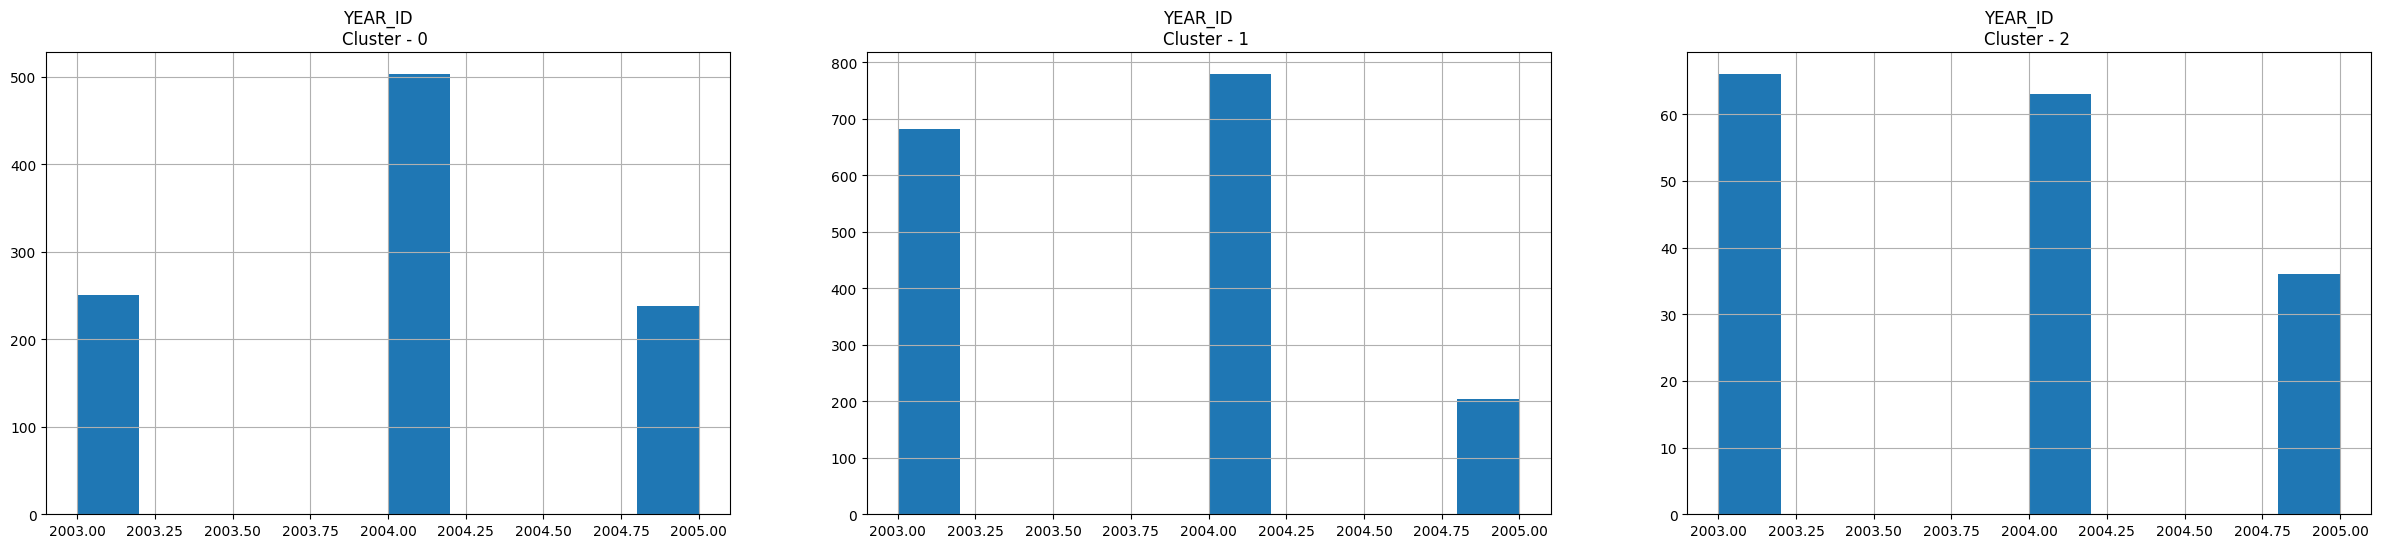

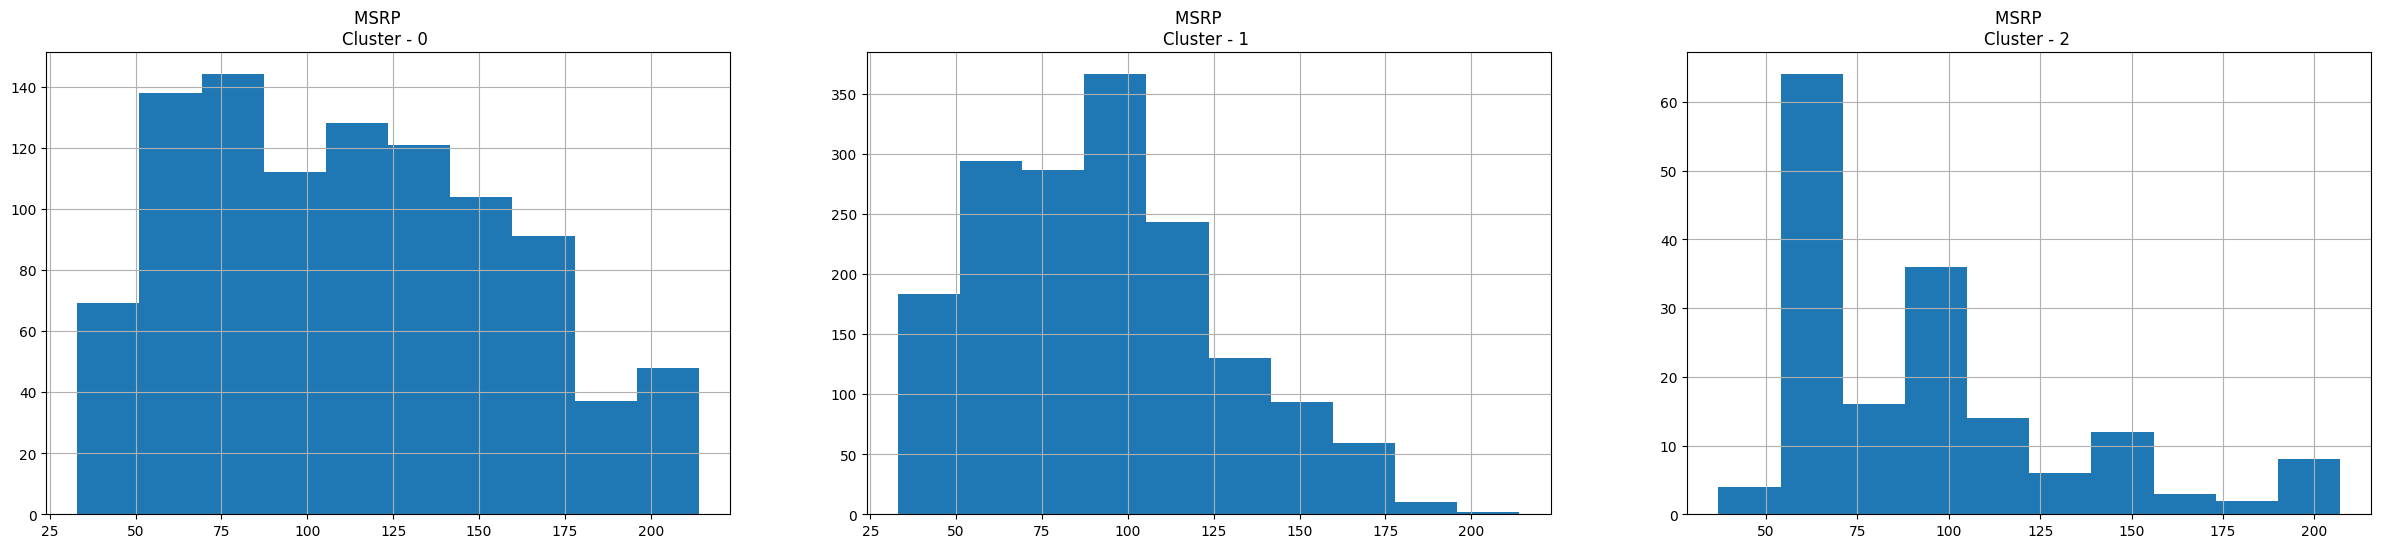

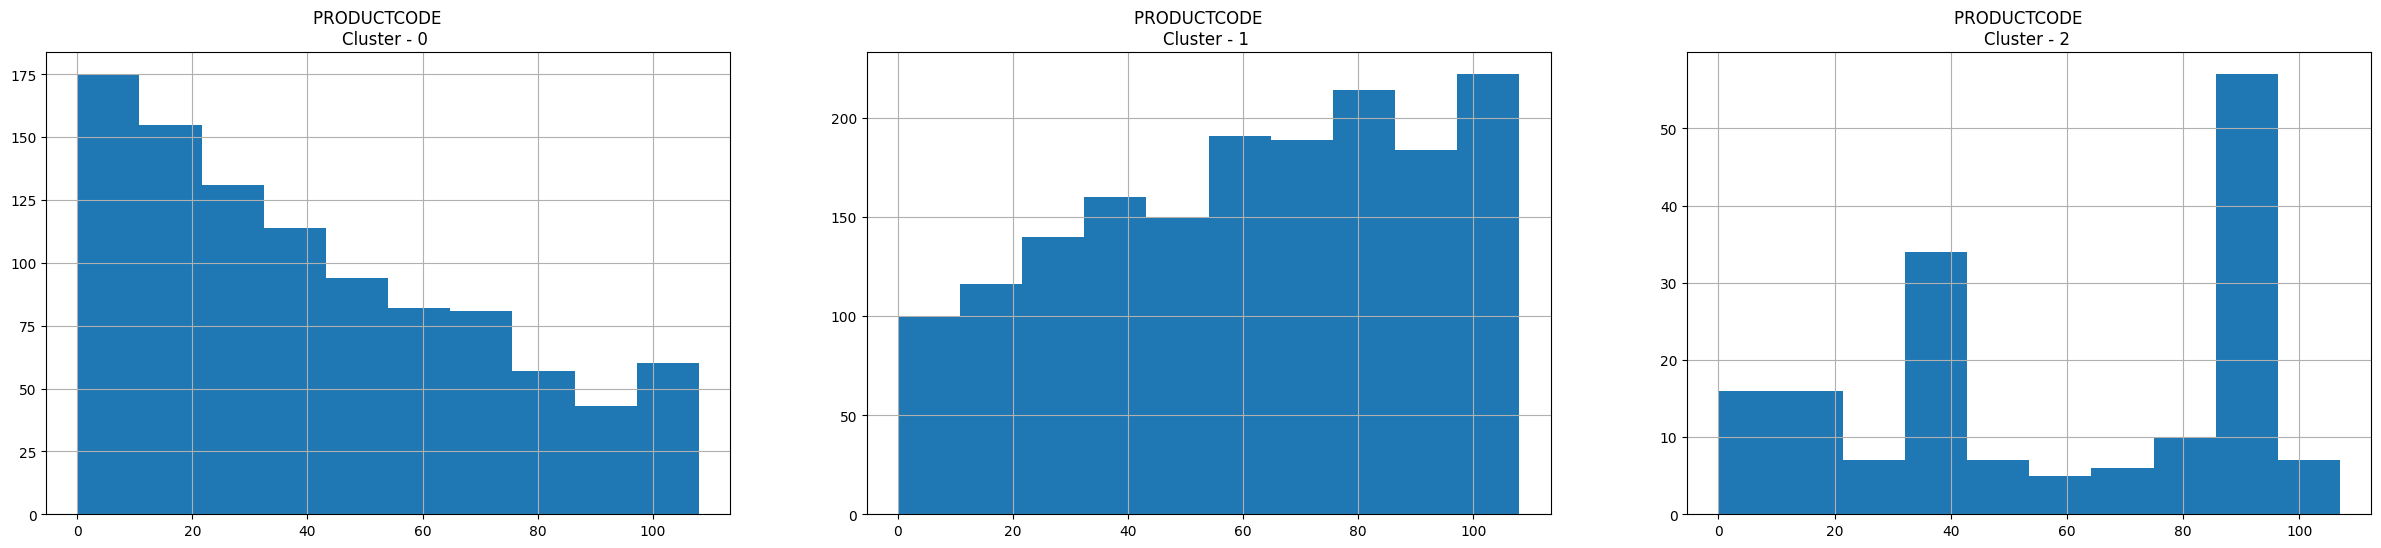

In [ ]:
#plot histograma for each feature based on cluster
for i in sales_df.columns [:8]:
  plt.figure (figsize = (30, 6))
  for j in range (3):
    plt.subplot(1, 3, j+1)
    cluster = df_cluster_dr[df_cluster_dr['cluster']== j]
    cluster[i].hist()
    plt.title('{}    \nCluster - {} '.format(i, j))
  plt.show()

In [ ]:
# Clúster 0: este grupo representa a los clientes que compran artículos en gran cantidad (47), por lo general compran artículos con precios altos (99). Aportan más ventas que otros grupos. En su mayoría están activos durante todo el año. Suelen comprar productos correspondientes al código de producto 10-90. Compran productos con un alto mrsp (158).
# Clúster 1: este grupo representa a los clientes que compran artículos en cantidad promedio (37) y que compran tienden a comprar artículos de precio alto (95). Aportan un promedio de ventas (4398) y están activos todo el año, son los mayores compradores de los productos correspondientes a los códigos de producto 0-10 y 90-100, además prefieren comprar productos con un PVPR elevado (115).
# Clúster 2: este grupo representa a los clientes que compran artículos en pequeñas cantidades (30), tienden a comprar artículos de bajo precio (69). Corresponden a la venta total más baja (2061) y están activos durante todo el año. Son los mayores compradores de productos correspondientes a los códigos de producto 0-20 y 100-110 y luego compran productos con PVPR bajo (77).

In [ ]:
pca = PCA (n_components= 3)
prin_comp = pca.fit_transform(sales_df_scaled)
pca_df = pd.DataFrame(data = prin_comp, columns= ['pca1', 'pca2', 'pca3'])
pca_df.head()

,pca1,pca2,pca3
0,-0.486319,1.195232,-1.002677
1,-0.784655,1.032832,-1.416265
2,1.431464,-0.121996,-0.281291
3,1.288425,0.218280,0.579360
4,1.976022,0.141698,1.061314


In [ ]:
pca_df = pd.concat([pca_df, pd.DataFrame({'cluster': labels})], axis = 1)
pca_df.head()

,pca1,pca2,pca3,cluster
0,-0.486319,1.195232,-1.002677,1
1,-0.784655,1.032832,-1.416265,0
2,1.431464,-0.121996,-0.281291,0
3,1.288425,0.218280,0.579360,1
4,1.976022,0.141698,1.061314,1


In [ ]:
#dsd

In [ ]:
# visualizar los cluster utilizando 3D-Scatterplot
fig = px.scatter_3d(pca_df, x = 'pca1', y = 'pca2', z = 'pca3',
                    color=labels, symbol=labels, size_max = 10, opacity = 0.7)
fig.update_layout(margin = dict(l = 0, r = 0, b = 0, t = 0))

MINI RETO #1:
  - Convertir la fecha del pedido en formato de fecha y hora usando Pandas
  - Verificar que la conversion fue exitosa imprimiendo el tipo de dato.

In [ ]:
sales_df ['ORDERDATE'] = pd.to_datetime(sales_df['ORDERDATE'])
sales_df.dtypes

KeyError: 'ORDERDATE'

MINI RETO #2:
¿Cuántos elementos nulos existen en 'ADDRESSLINE'?


In [ ]:
#comprobar el número de elementos no nulos
sales_df.info()
# Comprobar el número de elementos nulos
sales_df.isnull().sum()

MINI RETO #3:

- ¿Cúantos valores diferentes hay en el campo 'country'?
- ¿Cúantos códigos de productos únicos y lineas de productos?

In [ ]:
# Valores únicos de cada columna
sales_df.nunique()

MINI RETO #4:

- Cúantos valores de estado de pedido únicos tenemos?
- ¿Tenemos conjuntos de datos balanceados? Comentar el resultado y proponer soluciones

In [ ]:
# Exploremos la columna 'ESTADO'
barplot_visualization('STATUS')

# Los datos están desbalanceamos y en su mayoría contienen el estado 'enviado'
sales_df.drop(columns = ['STATUS'], inplace = True)
sales_df.shape

MINI RETO #5:
- Obtener dummies para la línea de productos y columnas de tamaño de oferta.
- Realizar una prueba de verificación y ver si la transformación es correcta.

In [ ]:
sales_df = dummies('PRODUCTLINE')
sales_df = dummies('DEALSIZE')
sales_df.head()

MINI RETO #6:
- Según los datos, ¿Cuándo alcanzan su punto máximo las ventas (en que mes)'
- Apoya tu respuesta con visualización / gráficos

In [ ]:
fig = px.line(x= sales_df_group.index, y = sales_df_group.SALES, title = 'SALES')
fig.show()


MINI RETO #7:
 - Representar la matriz de correlación enre variables.
 - Comentar los resultados de la matriz.

In [ ]:
plt.figure(figsize=(20, 20))
corr_matrix = sales_df.iloc[:, :9].corr()
sns.heatmap(corr_matrix, annot= True, cbar=False)

MINI RETO #8:

- Cambia el número de componentes a 2, modifica el codigo y vuelve a ejecutar
- Visualiza los clústeres usando graficos 2D

In [ ]:
pca = PCA (n_components=2)
principal_comp = pca.fit_transform(sales_df_scaled)

In [ ]:
# desplegarlo como queramos, con docker o como seaclústeres

In [ ]:
pca = PCA(n_components = 2)
principal_comp = pca.fit_transform(sales_df_scaled)

pca_df = pd.DataFrame(data = principal_comp, columns = ['pca1', 'pca2'])
pca_df = pd.concat([pca_df, pd.DataFrame({'cluster':labels})], axis = 1)

ax = sns.scatterplot(x = "pca1", y = "pca2", hue = "cluster", data = pca_df, palette = ["red", "green", "blue", "pink", "yellow"])
plt.show()

In [ ]:
print(sales_df.columns.tolist())

In [ ]:
import joblib
# Guardar el escalador
joblib.dump(scaler, 'scaler.pkl')
# El archivo autoencoder_1.weights.h5 ya lo tienes guardado

In [ ]:
import joblib

joblib.dump(pca, "pca.pkl")

['pca.pkl']